Uday Saini
B.Tech CSE
Sec-C
Roll no: 61
Cu24250246

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files


Saving imagescoll.jfif to imagescoll.jfif
Image loaded successfully!
Image size: (678, 452)


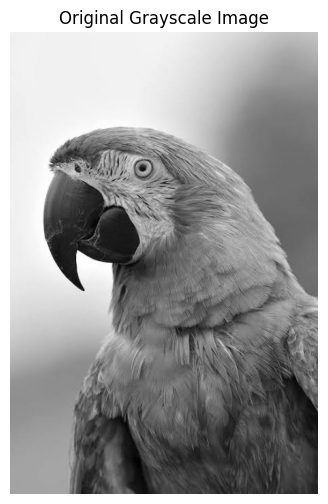

In [ ]:
uploaded = files.upload()

# Get uploaded filename
image_path = list(uploaded.keys())[0]

# Read image in grayscale
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if image is None:
    raise ValueError("Image could not be loaded. Please upload a valid image.")

print("Image loaded successfully!")
print("Image size:", image.shape)

plt.figure(figsize=(6, 6))
plt.imshow(image, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()

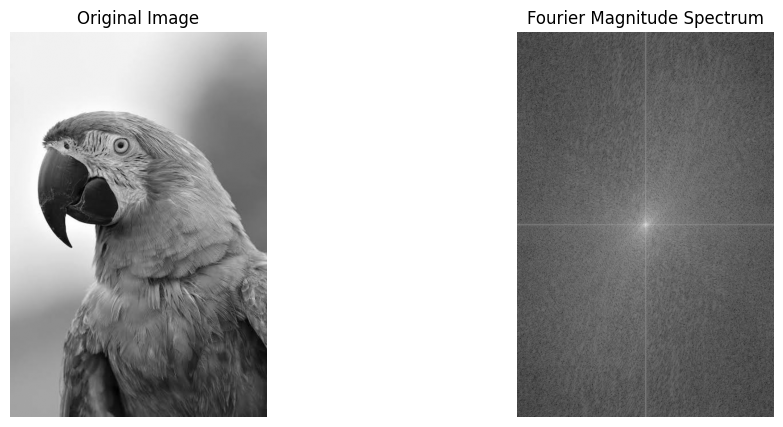

In [ ]:
# Convert image to float32
image_float = np.float32(image)

# Compute DFT
dft = cv2.dft(image_float, flags=cv2.DFT_COMPLEX_OUTPUT)

# Shift zero-frequency component to center
dft_shift = np.fft.fftshift(dft)

# Calculate magnitude spectrum
magnitude_spectrum = cv2.magnitude(
    dft_shift[:, :, 0],
    dft_shift[:, :, 1]
)

# Log transform for better visualization
magnitude_spectrum = 20 * np.log(magnitude_spectrum + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title("Fourier Magnitude Spectrum")
plt.axis("off")

plt.show()

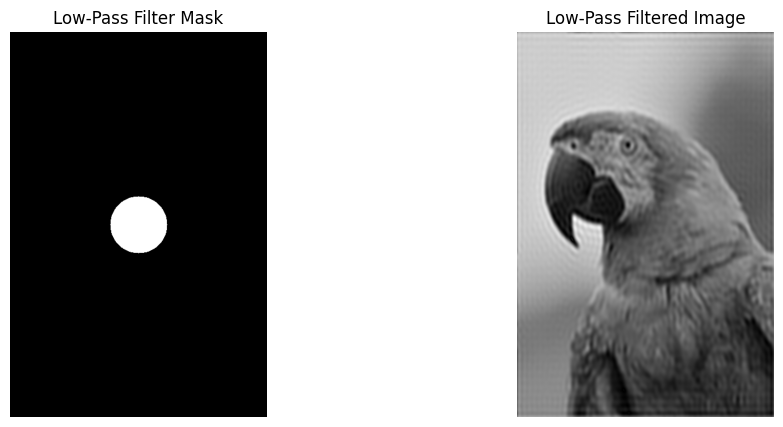

In [ ]:
rows, cols = image.shape
crow, ccol = rows // 2, cols // 2

# Radius of Low-Pass Filter
radius = 50

# Create mask
low_pass_mask = np.zeros((rows, cols, 2), np.float32)

y, x = np.ogrid[:rows, :cols]
distance = np.sqrt((x - ccol)**2 + (y - crow)**2)

low_pass_mask[distance <= radius] = 1

# Apply Low-Pass Filter
low_pass_dft = dft_shift * low_pass_mask

# Shift back
low_pass_ishift = np.fft.ifftshift(low_pass_dft)

# Inverse DFT
low_pass_image = cv2.idft(low_pass_ishift)

# Calculate magnitude
low_pass_image = cv2.magnitude(
    low_pass_image[:, :, 0],
    low_pass_image[:, :, 1]
)

# Normalize
low_pass_image = cv2.normalize(
    low_pass_image,
    None,
    0,
    255,
    cv2.NORM_MINMAX
)

low_pass_image = np.uint8(low_pass_image)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(low_pass_mask[:, :, 0], cmap='gray')
plt.title("Low-Pass Filter Mask")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(low_pass_image, cmap='gray')
plt.title("Low-Pass Filtered Image")
plt.axis("off")

plt.show()


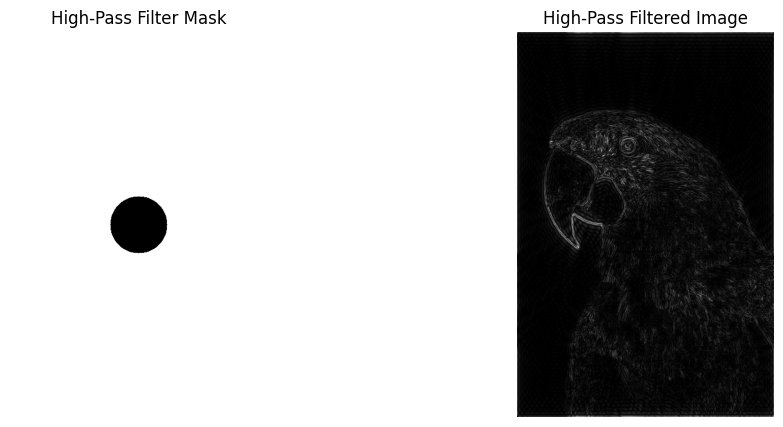

In [ ]:
# Create High-Pass Filter mask
high_pass_mask = np.ones((rows, cols, 2), np.float32)

high_pass_mask[distance <= radius] = 0

# Apply High-Pass Filter
high_pass_dft = dft_shift * high_pass_mask

# Shift back
high_pass_ishift = np.fft.ifftshift(high_pass_dft)

# Inverse DFT
high_pass_image = cv2.idft(high_pass_ishift)

# Calculate magnitude
high_pass_image = cv2.magnitude(
    high_pass_image[:, :, 0],
    high_pass_image[:, :, 1]
)

# Normalize
high_pass_image = cv2.normalize(
    high_pass_image,
    None,
    0,
    255,
    cv2.NORM_MINMAX
)

high_pass_image = np.uint8(high_pass_image)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(high_pass_mask[:, :, 0], cmap='gray')
plt.title("High-Pass Filter Mask")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(high_pass_image, cmap='gray')
plt.title("High-Pass Filtered Image")
plt.axis("off")

plt.show()

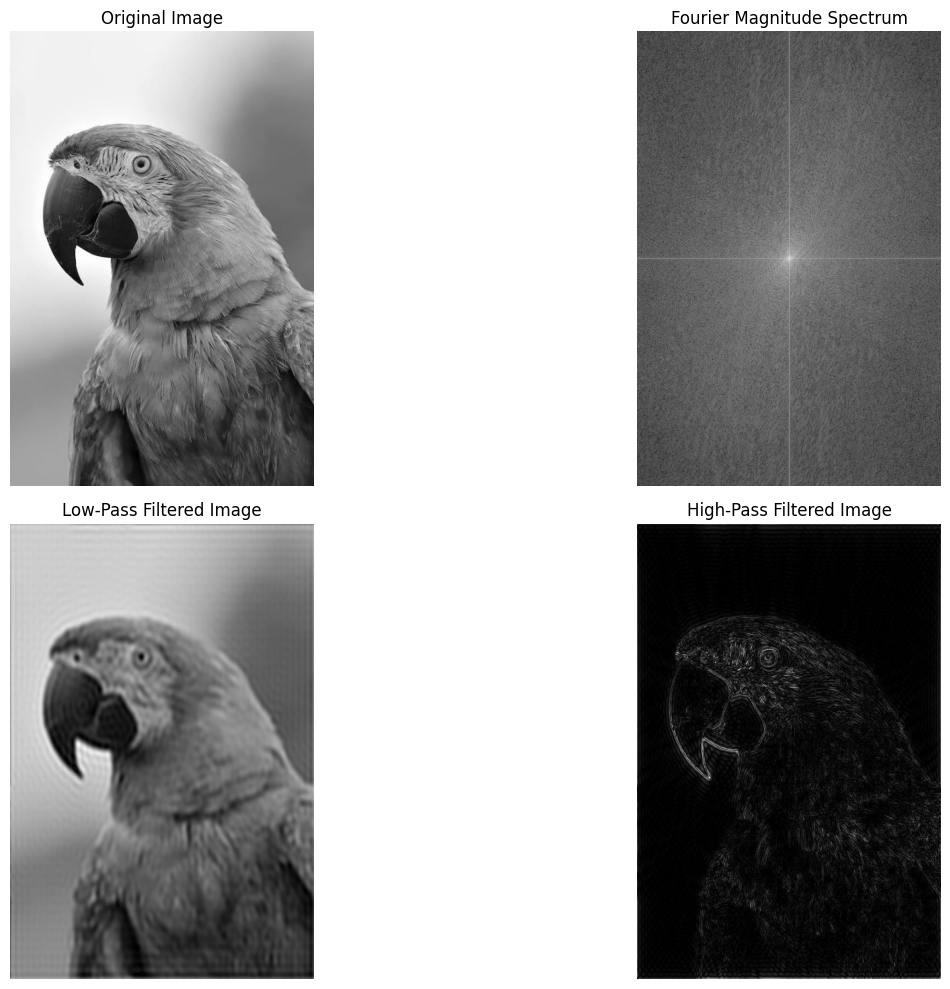

In [ ]:
plt.figure(figsize=(16, 10))

plt.subplot(2, 2, 1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title("Fourier Magnitude Spectrum")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(low_pass_image, cmap='gray')
plt.title("Low-Pass Filtered Image")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(high_pass_image, cmap='gray')
plt.title("High-Pass Filtered Image")
plt.axis("off")

plt.tight_layout()
plt.show()